In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import pprint

import hydra
from omegaconf import OmegaConf
import polars as pl
import numpy as np
import torch
from einops import reduce
import lightning.pytorch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=2)

import conf.dataset
from conf import conf
from g_led import datasets, models, utils

In [3]:
engine = conf.get_engine()
conf.orm.create_all(engine)
db = conf.sa.orm.Session(engine, expire_on_commit=False)
db.begin()

In [4]:
alt_id_runs = pl.DataFrame(
    orient='row',
    schema=[
        'alt_id', 'label',
    ],
    data=[
        ['nzgq1sx1', 'Imagen'],
    ],
)

In [5]:
# special runs
TRUE_RUN = 'True'
LINEAR_INTERPOLATION_TRUE_RUN = 'LinearInterpolationTrue'
# dynamic special runs (end in underscore)
LINEAR_INTERPOLATION_FORECAST_RUN = 'LinearInterpolationForecast_'
special_runs = pl.DataFrame(
    orient='row',
    schema=[
        'id', 'label',
    ],
    data=[
        [TRUE_RUN, 'True'],
        [LINEAR_INTERPOLATION_TRUE_RUN, 'Interp. (True)'],
    ],
)
dynamic_special_runs = pl.DataFrame(
    orient='row',
    schema=['special', 'dynamic_id', 'dynamic_label'],
    data=[
        [True, LINEAR_INTERPOLATION_FORECAST_RUN, 'Forecast Interp.'],
        [False, '', ''],
    ],
)
runs = (
    alt_id_runs.join(dynamic_special_runs, how='cross')
    .select(
        pl.when('special').then('dynamic_id').otherwise('alt_id').alias('id'),
        pl.col('alt_id'),
        pl.when('special').then(pl.col('dynamic_label') + ' (' + pl.col('label') + ')').otherwise('label').alias('label'),
        pl.col('special'),
    )
)
runs = (
    pl.concat([
        special_runs.select(
            pl.col('id'),
            pl.lit('').alias('alt_id'),
            pl.col('label'),
            pl.lit(True).alias('special'),
        ),
        runs
    ])
    .with_columns(key=pl.int_range(pl.len()).cast(str))
)
def iter_runs(include_special=False, **kwargs):
    if 'named' not in kwargs:
        kwargs['named'] = True
    for row in runs.iter_rows(**kwargs):
        if include_special or not row['special']:
            yield row
runs

id,alt_id,label,special,key
str,str,str,bool,str
"""True""","""""","""True""",true,"""0"""
"""LinearInterpolationTrue""","""""","""Interp. (True)""",true,"""1"""
"""LinearInterpolationForecast_""","""nzgq1sx1""","""Forecast Interp. (Imagen)""",true,"""2"""
"""nzgq1sx1""","""nzgq1sx1""","""Imagen""",false,"""3"""


In [7]:
cfgs = db.execute(conf.sa.select(conf.Conf).where(conf.Conf.alt_id.in_(runs.get_column('alt_id'))))
cfgs = {cfg.alt_id: {'cfg': cfg} for (cfg,) in cfgs}
context = defaultdict(dict)
for run in iter_runs():
    cfg = cfgs[run['alt_id']]['cfg']
    context[run['key']] = {'cfg': cfg}
    context[run['key']]['window_pred'] = torch.load(cfg.run_dir/'pred.pt')
    
    lightning.pytorch.seed_everything(cfg.rng_seed)
    with lightning.pytorch.utilities.seed.isolate_rng():
        dataset = datasets.get_dataset(cfg.dataset)
        dataset.prepare_data()
        dataset.setup('predict')
    downsampler = dataset.downsampler
    upsampler = models.Upsampler(downsampler.cfg)

    context[runs.filter(id=LINEAR_INTERPOLATION_FORECAST_RUN, alt_id=run['alt_id'])['key'][0]]['window_pred'] = upsampler(
        dataset.trajectories_macro[:, cfg.dataset.initial_sequence_time_step_count:]
    )
    
window = dataset.trajectories_micro[:, cfg.dataset.initial_sequence_time_step_count:]
context[runs.filter(id=TRUE_RUN)['key'][0]]['window_pred'] = window
context[runs.filter(id=LINEAR_INTERPOLATION_TRUE_RUN)['key'][0]]['window_pred'] = upsampler(downsampler(window))

max_key_len = runs.select(pl.col('key').str.len_chars().max())['key'][0]
for run in iter_runs(include_special=True):
    if run['key'] in context:
        print(f"{run['key']}{':':<{max_key_len+1}}{context[run['key']]['window_pred'].shape}")

Seed set to 2376999025


0: torch.Size([1, 150, 2, 512, 512])
1: torch.Size([1, 150, 2, 512, 512])
2: torch.Size([1, 150, 2, 512, 512])
3: torch.Size([1, 150, 2, 512, 512])


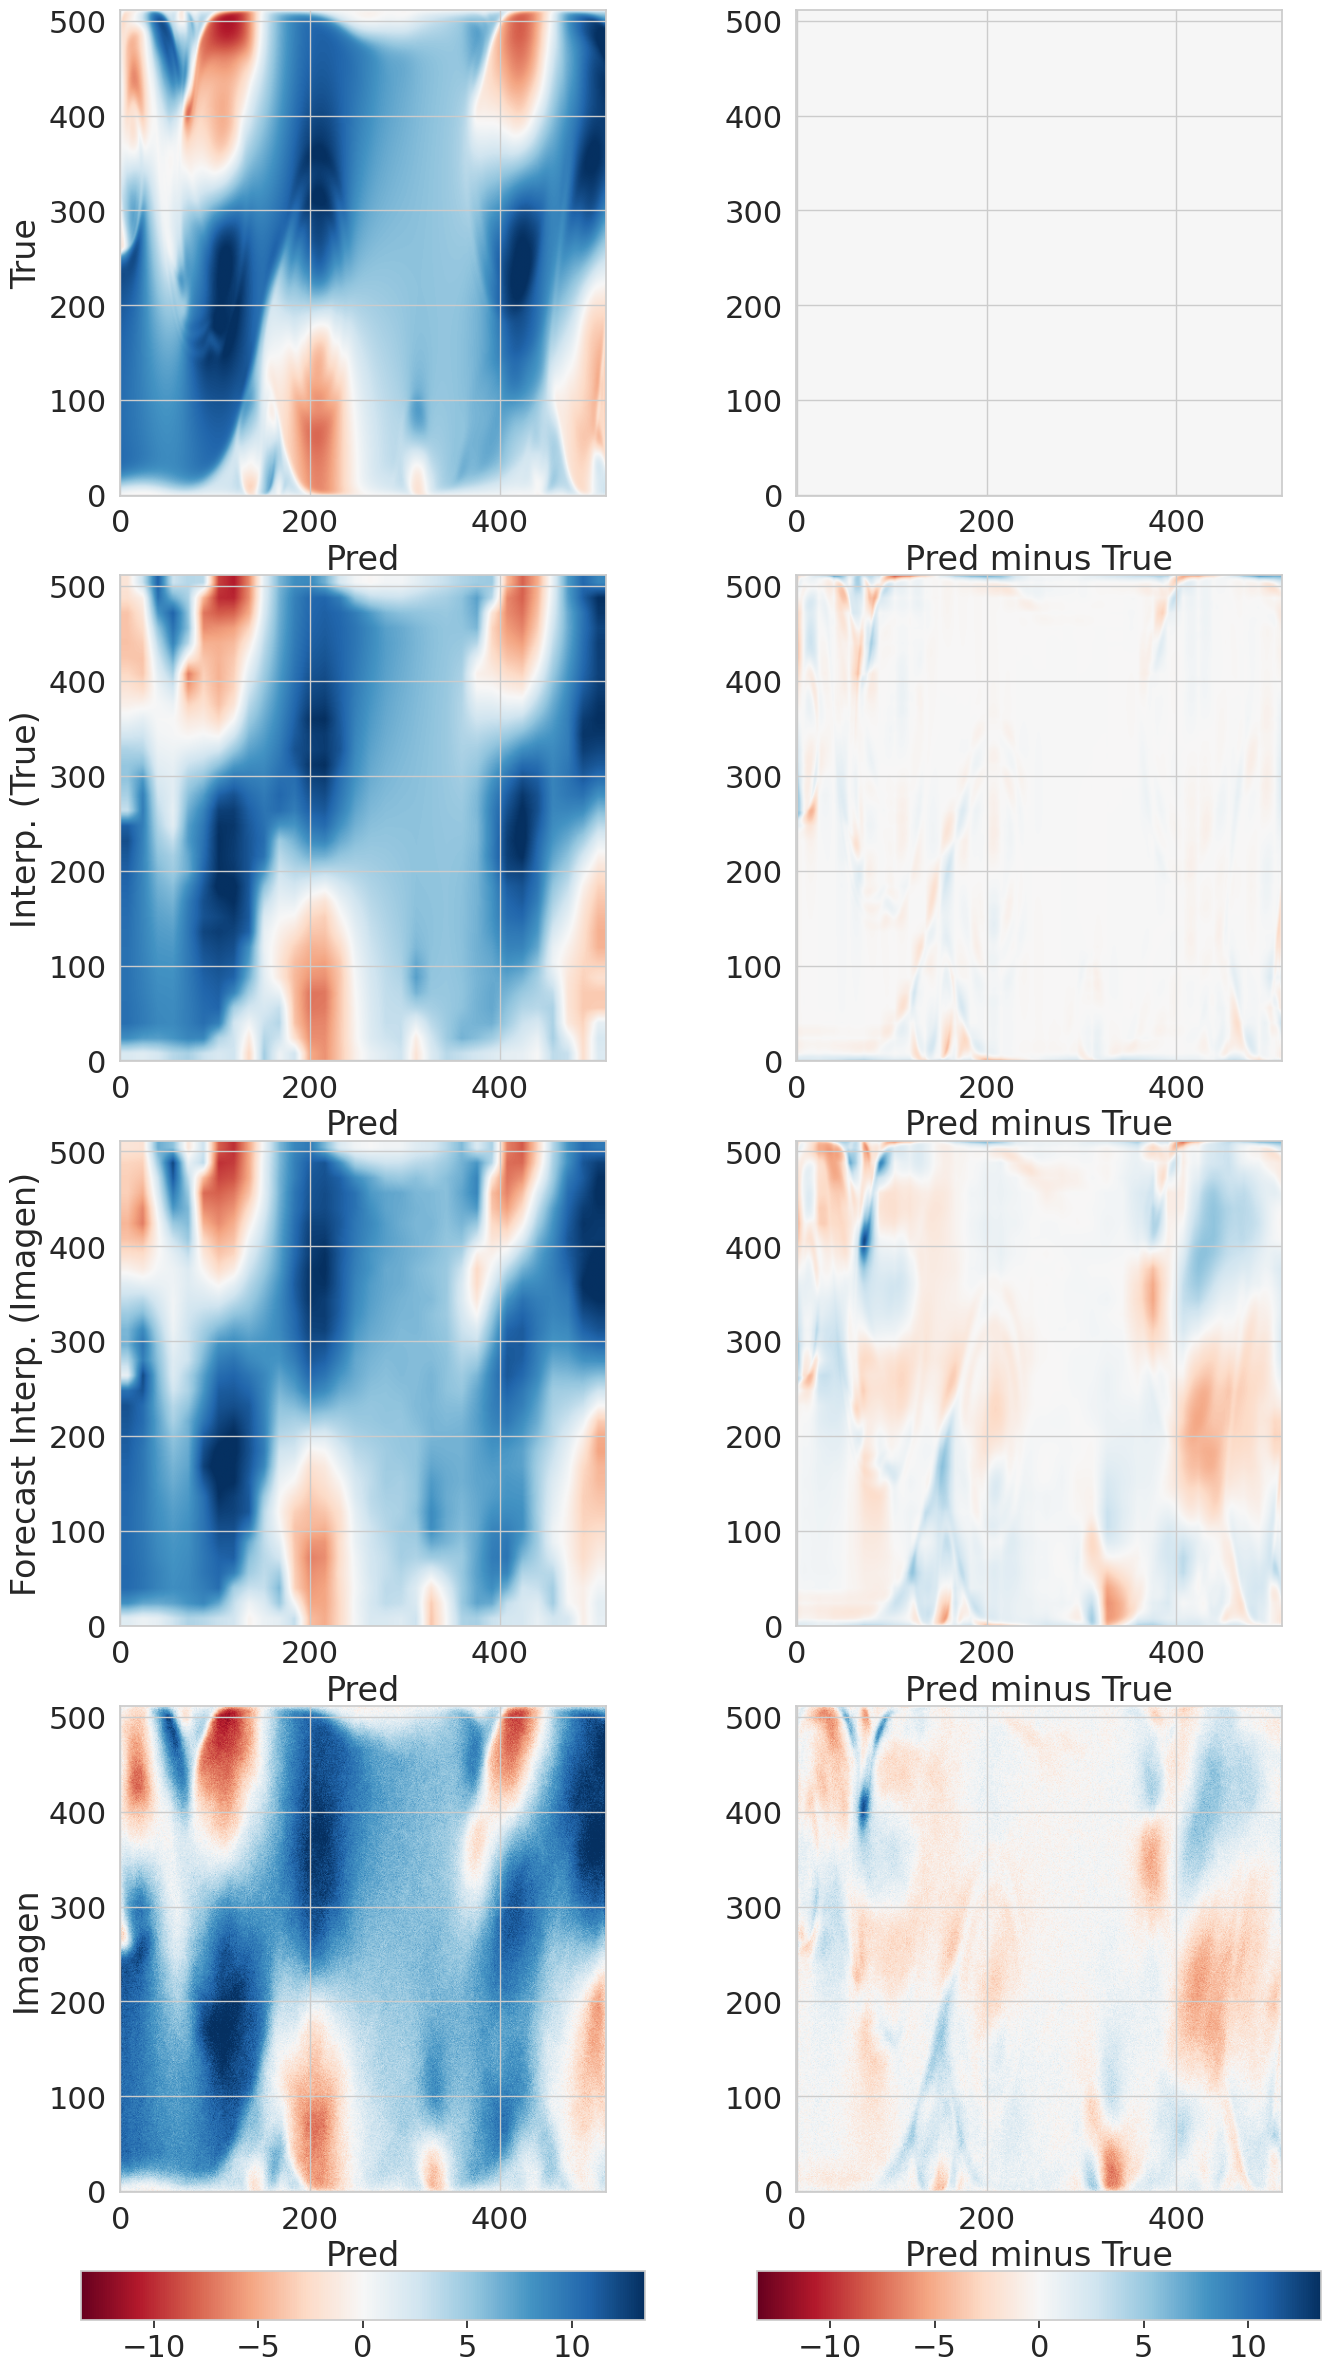

In [8]:
trajectory = 0
time_step = -1
component = 0

data_true = context[runs.filter(id=TRUE_RUN)['key'][0]]['window_pred'][trajectory, time_step, component]
p = .01
v_abs_max = max(np.quantile(data_true, p), np.quantile(data_true, 1 - p))

plot_context = {
    k: context[k]['window_pred'][trajectory, time_step, component] for k in runs.get_column('key')
}
fig, axs = plt.subplots(figsize=(16, 6 + 6 * len(plot_context)), nrows=len(plot_context) + 1, ncols=2, height_ratios=[*([10] * len(plot_context)), 1])
for axs_row, (k, data) in zip(axs, plot_context.items()):
    im_out_pred = axs_row[0].imshow(data, cmap='RdBu', origin='lower', vmin=-v_abs_max, vmax=v_abs_max)
    run = runs.filter(key=k)
    axs_row[0].set_xlabel('Pred')
    axs_row[0].set_ylabel(run['label'][0])
    im_out_err = axs_row[1].imshow(data - data_true, cmap='RdBu', origin='lower', vmin=-v_abs_max, vmax=v_abs_max)
    axs_row[1].set_xlabel('Pred minus True')
fig.colorbar(im_out_pred, cax=axs[-1][0], orientation='horizontal')
fig.colorbar(im_out_err, cax=axs[-1][1], orientation='horizontal')

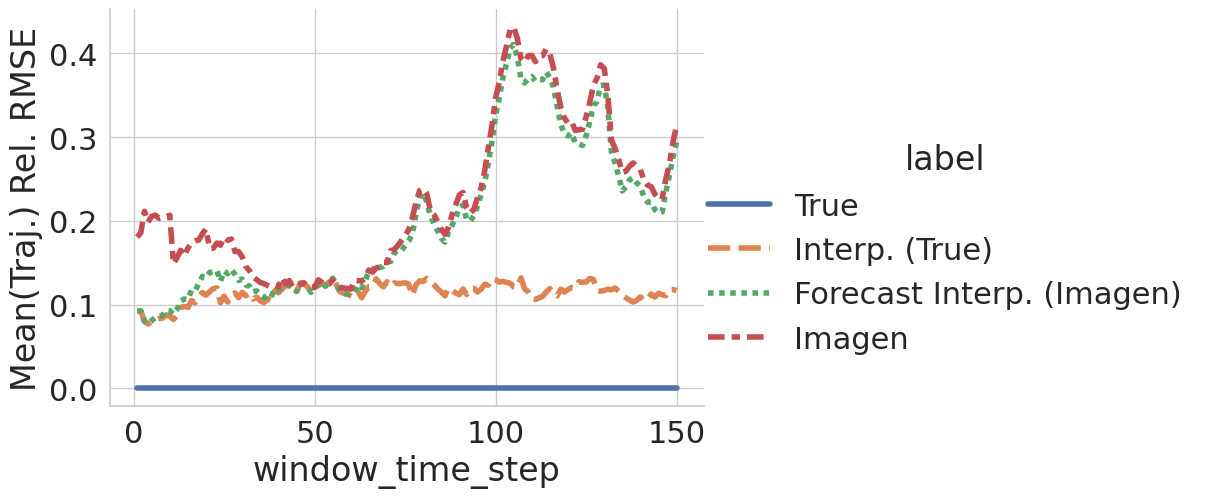

In [9]:
data_true = context[runs.filter(id=TRUE_RUN)['key'][0]]['window_pred']
rel_rmses = {}
for k, v in context.items():
    data = v['window_pred']
    rmse = reduce(
        (data - data_true).square(),
        'trajectory time component width length -> trajectory time',
        'mean'
    ).sqrt()
    norm = reduce(
        data_true.square(),
        'trajectory time component width length -> trajectory time',
        'mean'
    ).sqrt()
    rel_rmses[k] = (rmse / norm).mean(0).numpy()
rel_rmses = pl.DataFrame(rel_rmses).with_columns(window_time_step=pl.int_range(1, pl.len()+1))
# print(rel_rmses)
plot_data = (
    rel_rmses
    .unpivot(index='window_time_step', variable_name='key', value_name='Mean(Traj.) Rel. RMSE')
    .join(runs, on='key')
)
# print(plot_data)
row_order = runs.sort('key').get_column('label')
plot_rmse = (
    sns.relplot(
        kind='line',
        data=plot_data,
        x='window_time_step',
        y='Mean(Traj.) Rel. RMSE',
        hue_order=row_order,
        style_order=row_order,
        hue='label',
        style='label',
        markers=data_true.shape[1] <= 100,
        linewidth=4,
        markersize=12,
        height=5.5,
        aspect=1.5,
    )
)